<a href="https://www.kaggle.com/code/lalit7881/teen-social-media-mental-health-eda?scriptVersionId=314478449" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sureshbeekhani/teen-social-media-usage-and-mental-health/Teen_Mental_Health_Dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sureshbeekhani/teen-social-media-usage-and-mental-health/Teen_Mental_Health_Dataset.csv")

In [3]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high
2,17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low
3,19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium
4,15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low


In [4]:
df.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
2495,17,male,3.7,Other,6.1,1.8,2.82,0.4,low,5,5,medium
2496,17,female,7.4,TikTok,4.0,2.6,2.32,1.4,medium,9,9,medium
2497,15,female,6.3,Both,5.0,1.6,2.35,1.2,high,9,10,medium
2498,17,female,4.5,TikTok,6.7,1.9,2.90,0.4,medium,7,7,medium
2499,13,female,7.9,Instagram,4.4,1.8,2.42,0.5,high,10,9,medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   object 
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   object 
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interaction_level  2500 non-null   object 
 9   stress_level              2500 non-null   int64  
 10  anxiety_level             2500 non-null   int64  
 11  depression_risk           2500 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 234.5+ KB


In [6]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,15.978000,4.45804,6.192440,1.714760,2.890944,0.991760,5.596400,5.164800
std,2.003577,2.01693,1.018734,0.716636,0.559553,0.586963,3.039013,3.002473
min,13.000000,1.00000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000
25%,14.000000,2.70000,5.500000,1.100000,2.420000,0.500000,3.000000,2.000000
50%,16.000000,4.40000,6.200000,1.700000,2.880000,1.000000,6.000000,5.000000
75%,18.000000,6.20000,6.900000,2.300000,3.340000,1.500000,8.000000,8.000000
max,19.000000,8.00000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000


In [7]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
depression_risk             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
depression_risk              object
dtype: object

In [10]:
df.shape

(2500, 12)

In [11]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'depression_risk'],
      dtype='object')

In [12]:
df.nunique()

age                           7
gender                        2
daily_social_media_hours     71
platform_usage                4
sleep_hours                  51
screen_time_before_sleep     26
academic_performance        200
physical_activity            21
social_interaction_level      3
stress_level                 10
anxiety_level                10
depression_risk               3
dtype: int64

## EDA

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   19    male                       3.8      Instagram          6.5   
1   16    male                       6.5          Other          5.8   
2   17  female                       2.9          Other          7.0   
3   19  female                       7.9         TikTok          5.0   
4   15  female                       1.2         TikTok          8.8   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       1.7                  2.77                1.2   
1                       0.6                  2.57                0.2   
2                       1.2                  3.04                1.7   
3                       1.6                  2.21                1.2   
4                       0.9                  3.61                1.9   

  social_interaction_level  stress_level  anxiety_level depression_risk  
0                      low             6              6     

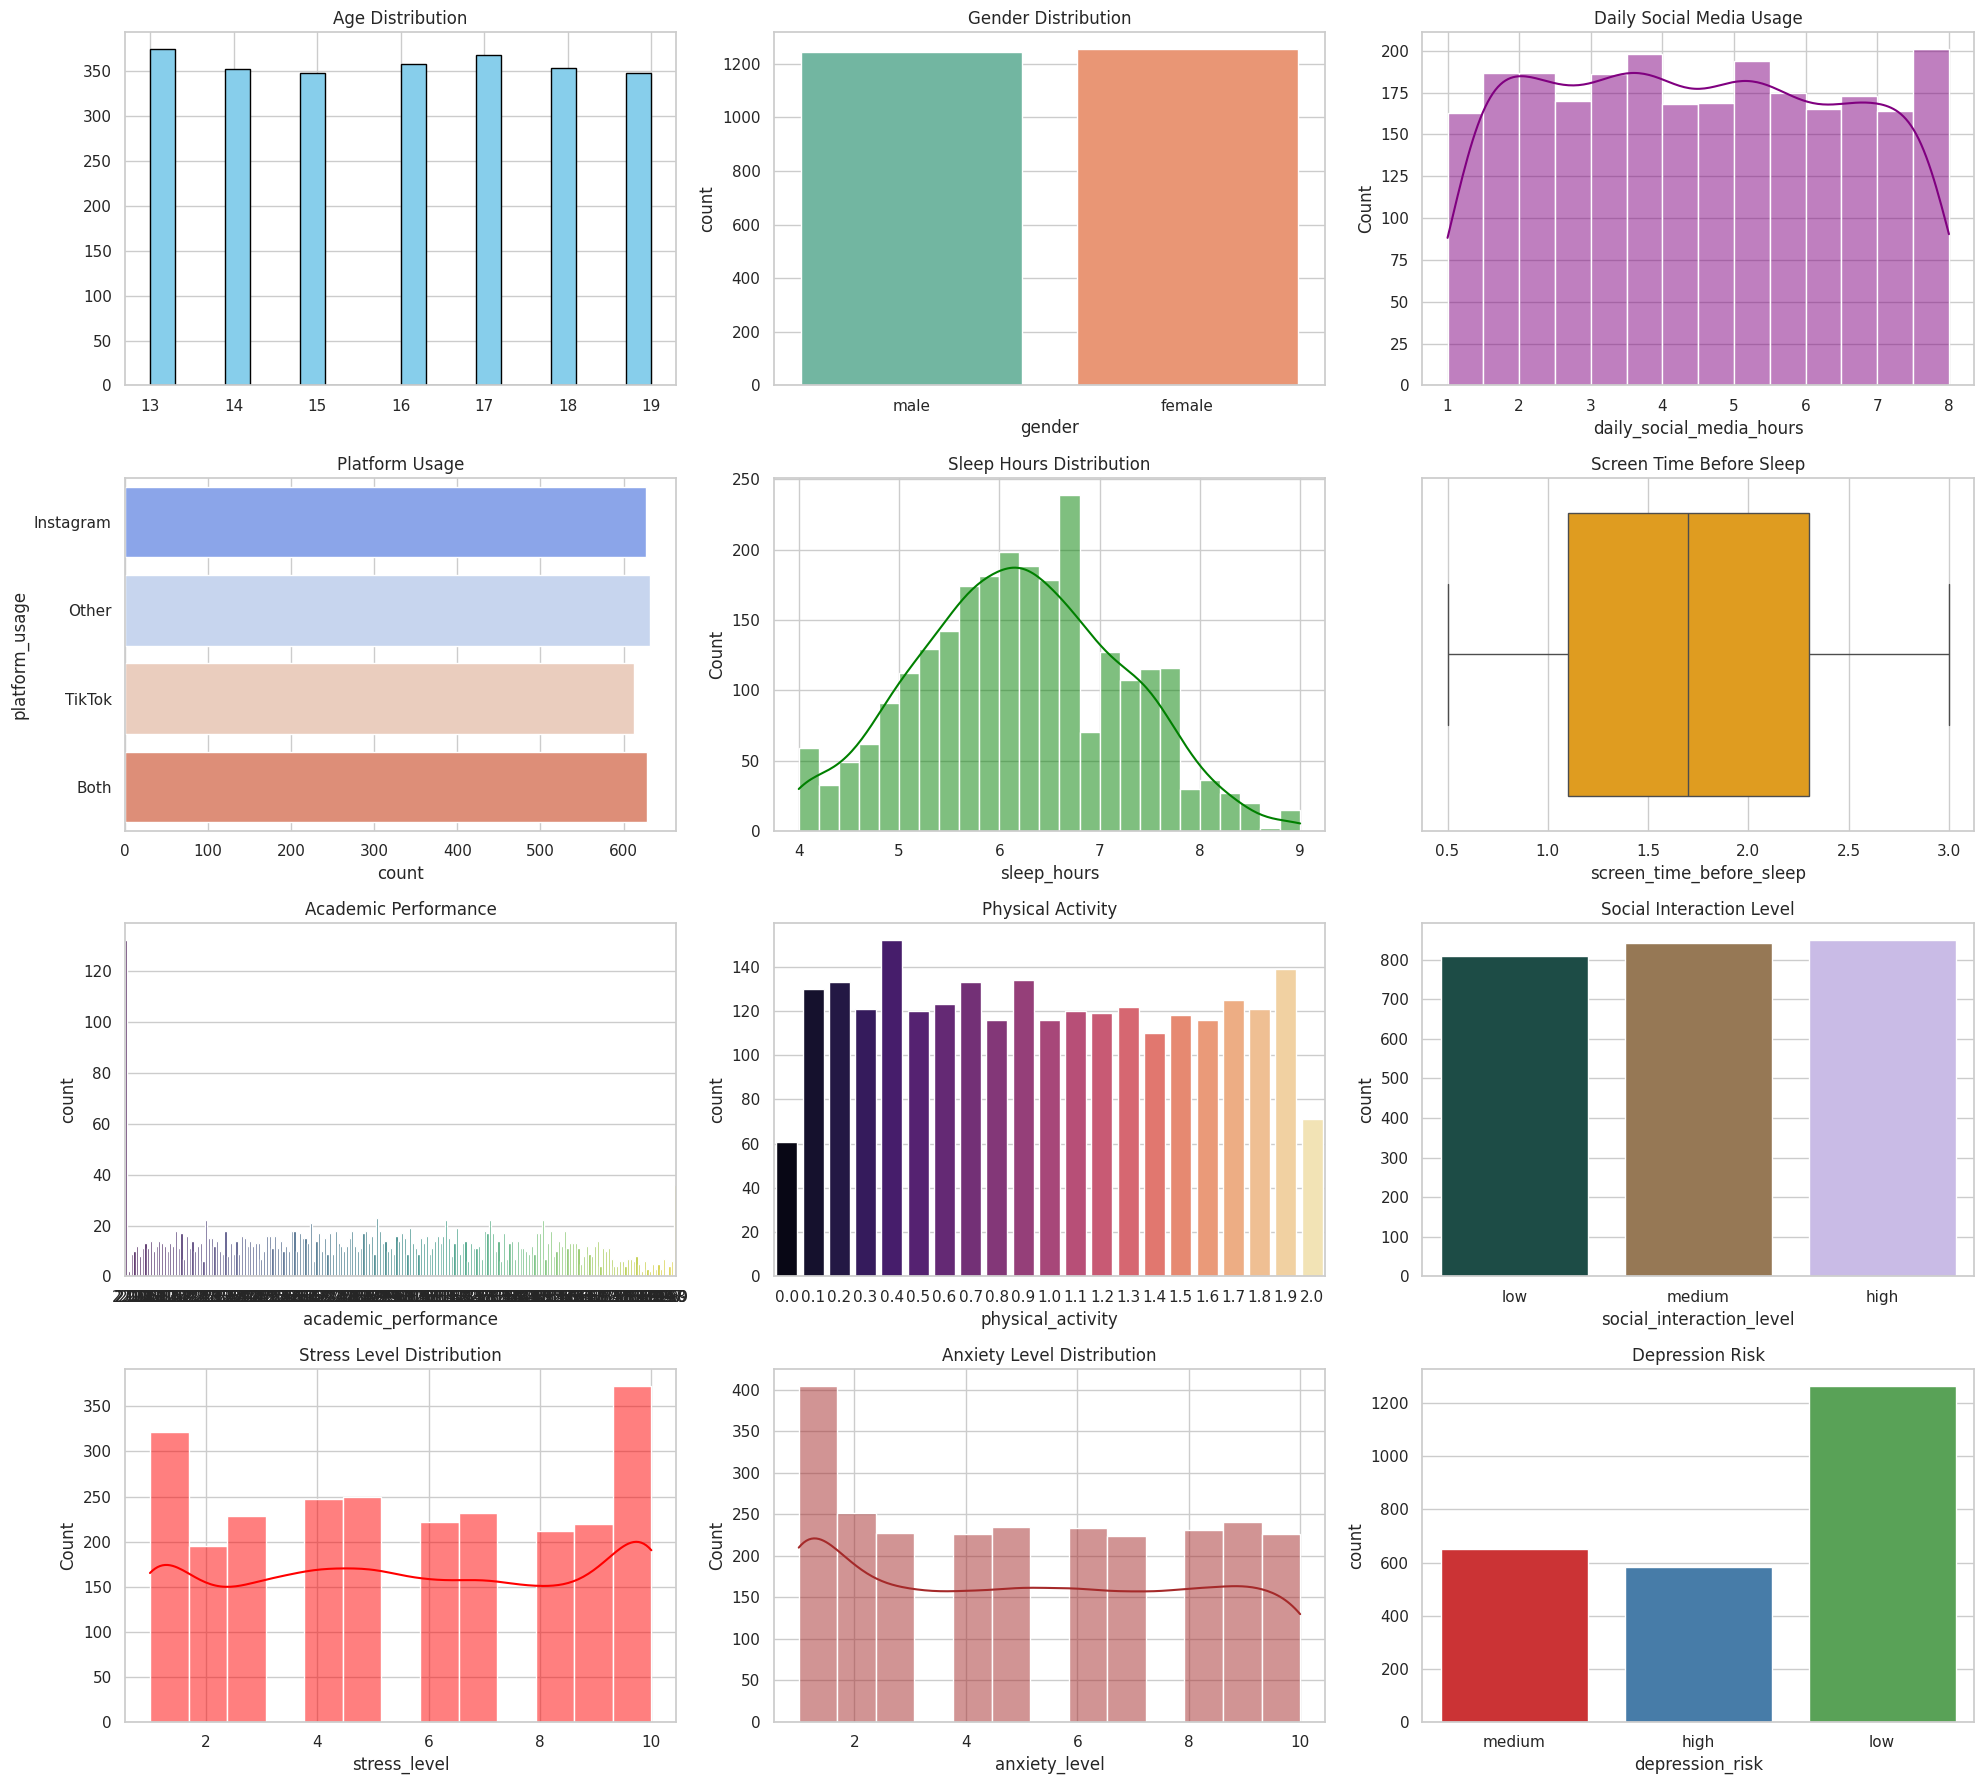

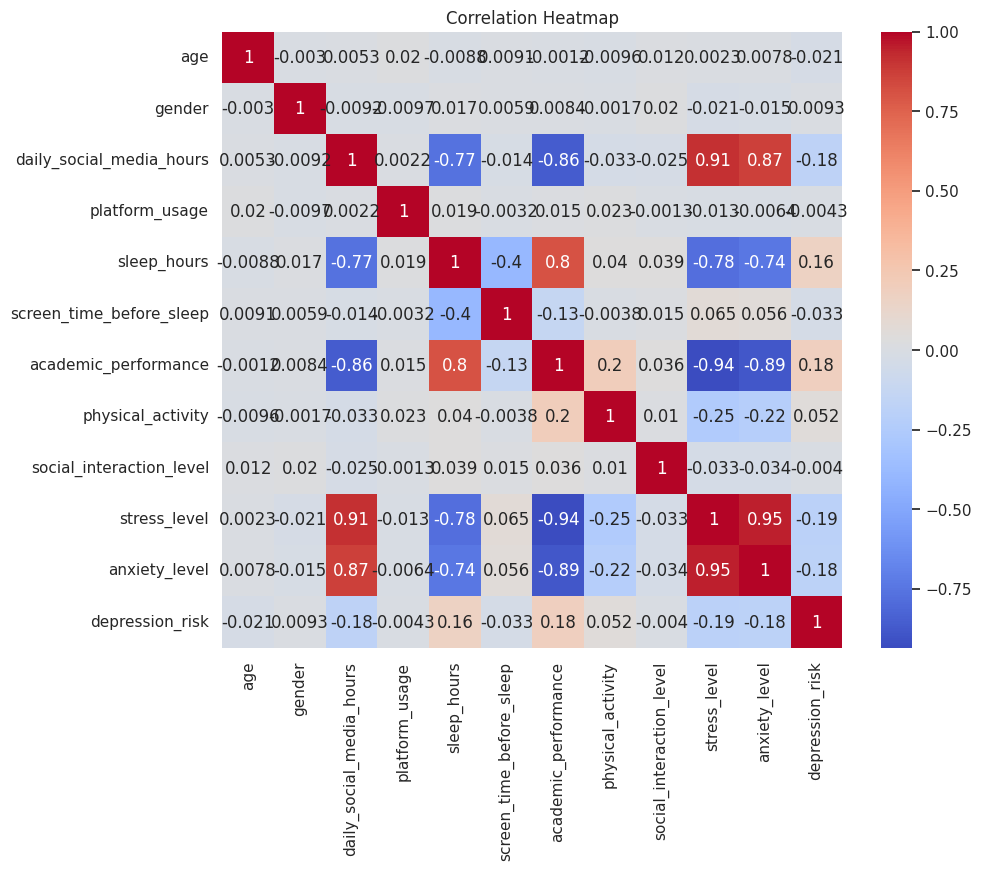

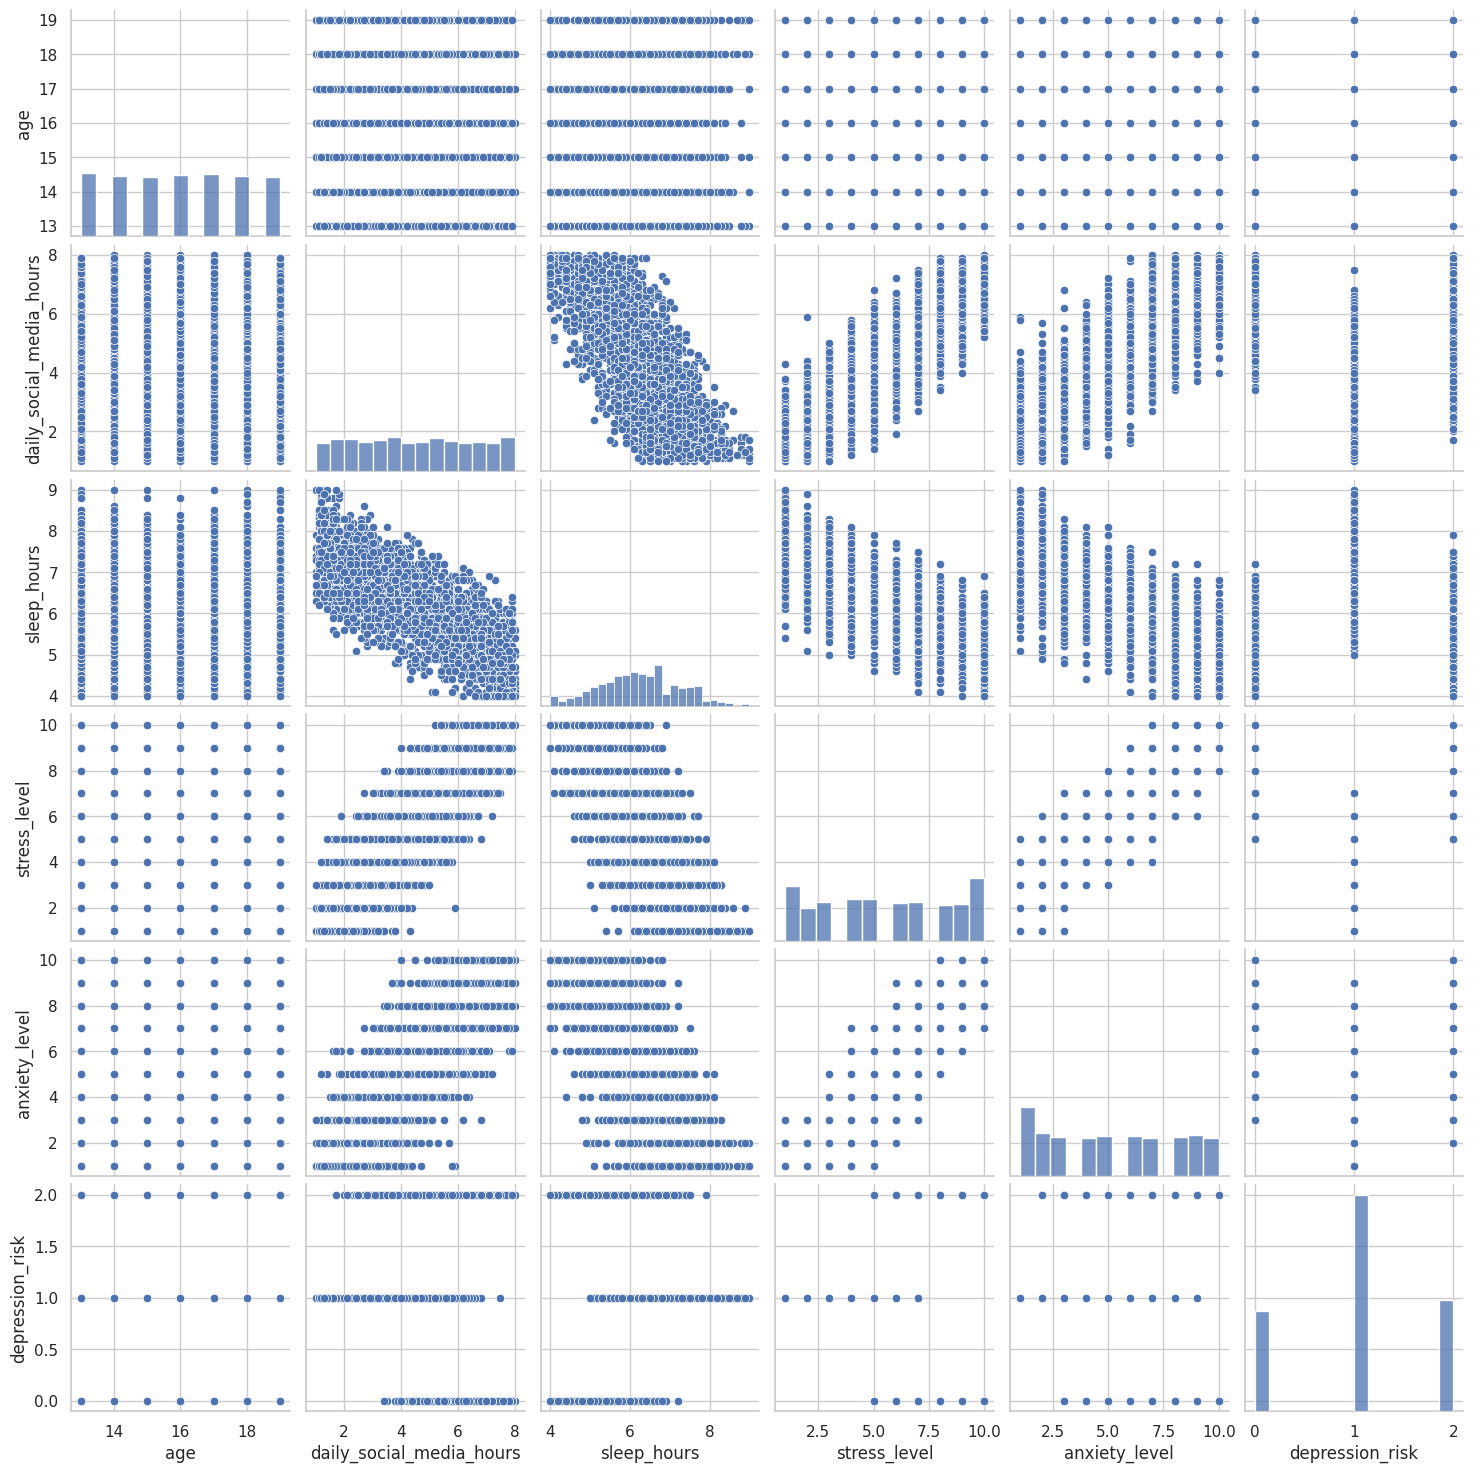

In [13]:

# Style
sns.set(style="whitegrid")

# Preview
print(df.head())

# ==============================
# 3. Basic Info
# ==============================
print(df.info())
print(df.describe())

# ==============================
# 4. Visualization
# ==============================

plt.figure(figsize=(20, 18))

# 1. Age Distribution
plt.subplot(4, 3, 1)
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title("Age Distribution")

# 2. Gender Count
plt.subplot(4, 3, 2)
sns.countplot(x='gender', data=df, palette='Set2')
plt.title("Gender Distribution")

# 3. Daily Social Media Hours
plt.subplot(4, 3, 3)
sns.histplot(df['daily_social_media_hours'], kde=True, color='purple')
plt.title("Daily Social Media Usage")

# 4. Platform Usage
plt.subplot(4, 3, 4)
sns.countplot(y='platform_usage', data=df, palette='coolwarm')
plt.title("Platform Usage")

# 5. Sleep Hours
plt.subplot(4, 3, 5)
sns.histplot(df['sleep_hours'], kde=True, color='green')
plt.title("Sleep Hours Distribution")

# 6. Screen Time Before Sleep
plt.subplot(4, 3, 6)
sns.boxplot(x='screen_time_before_sleep', data=df, color='orange')
plt.title("Screen Time Before Sleep")

# 7. Academic Performance
plt.subplot(4, 3, 7)
sns.countplot(x='academic_performance', data=df, palette='viridis')
plt.title("Academic Performance")

# 8. Physical Activity
plt.subplot(4, 3, 8)
sns.countplot(x='physical_activity', data=df, palette='magma')
plt.title("Physical Activity")

# 9. Social Interaction Level
plt.subplot(4, 3, 9)
sns.countplot(x='social_interaction_level', data=df, palette='cubehelix')
plt.title("Social Interaction Level")

# 10. Stress Level
plt.subplot(4, 3, 10)
sns.histplot(df['stress_level'], kde=True, color='red')
plt.title("Stress Level Distribution")

# 11. Anxiety Level
plt.subplot(4, 3, 11)
sns.histplot(df['anxiety_level'], kde=True, color='brown')
plt.title("Anxiety Level Distribution")

# 12. Depression Risk
plt.subplot(4, 3, 12)
sns.countplot(x='depression_risk', data=df, palette='Set1')
plt.title("Depression Risk")

plt.tight_layout()
plt.show()

# ==============================
# 5. Correlation Heatmap
# ==============================
plt.figure(figsize=(10,8))

# Convert categorical if needed
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 6. Pairplot (Important Relationships)
# ==============================
sns.pairplot(df_encoded[['age','daily_social_media_hours','sleep_hours',
                         'stress_level','anxiety_level','depression_risk']])
plt.show()

## Feture engineering


Logistic Regression Accuracy: 0.7160

Logistic Regression Classification Report:

              precision    recall  f1-score   support

        high       0.69      0.71      0.70       117
         low       0.86      0.87      0.86       253
      medium       0.45      0.42      0.44       130

    accuracy                           0.72       500
   macro avg       0.66      0.67      0.67       500
weighted avg       0.71      0.72      0.71       500


Random Forest Accuracy: 0.7520

Random Forest Classification Report:

              precision    recall  f1-score   support

        high       0.70      0.93      0.80       117
         low       0.90      0.81      0.85       253
      medium       0.53      0.48      0.50       130

    accuracy                           0.75       500
   macro avg       0.71      0.74      0.72       500
weighted avg       0.76      0.75      0.75       500


SVM Accuracy: 0.7580

SVM Classification Report:

              precision    recall

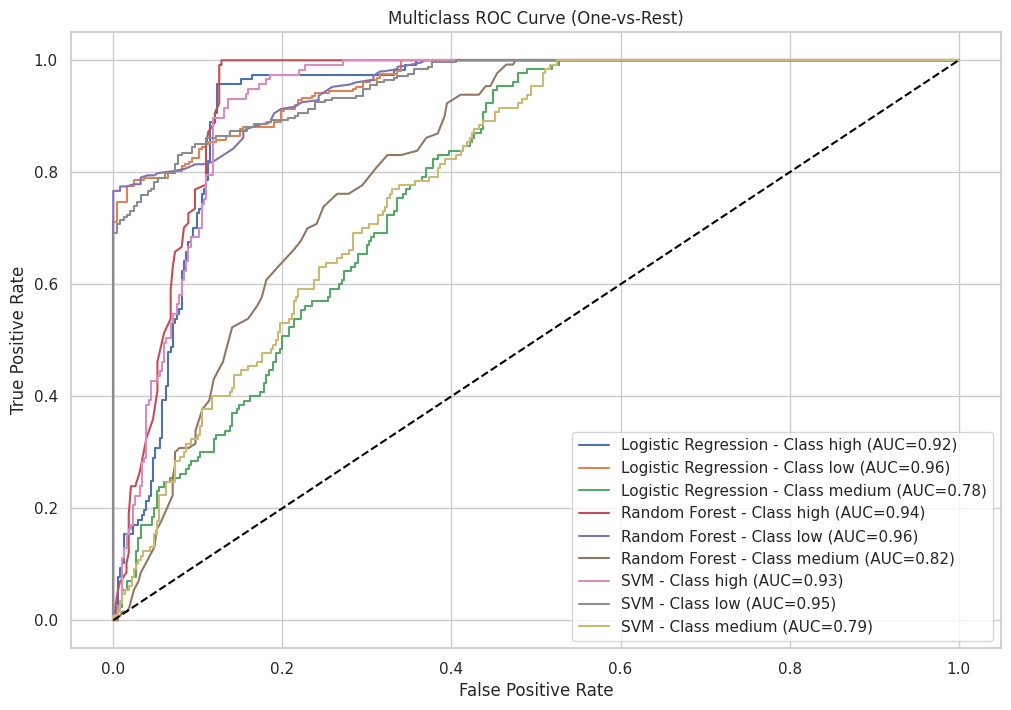


Final Model Accuracy Comparison:

Logistic Regression: 0.7160
Random Forest: 0.7520
SVM: 0.7580


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc


# Handle missing values
df = df.dropna()

# ==========================================
# 3. Define Features & Target
# ==========================================
target = 'depression_risk'

X = df.drop(columns=[target])
y = df[target]

# Encode target (MULTICLASS SAFE)
le = LabelEncoder()
y = le.fit_transform(y)

# ==========================================
# 4. Train-Test Split (NO LEAKAGE)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 5. Column Types
# ==========================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# ==========================================
# 6. Preprocessing Pipeline
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# ==========================================
# 7. Models
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, multi_class='multinomial'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

# ==========================================
# 8. Training + Evaluation
# ==========================================
results = {}

# For ROC (multiclass)
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(12,8))

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    # Classification Report
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # ROC Curve (One-vs-Rest)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} - Class {le.classes_[i]} (AUC={roc_auc:.2f})")

# Baseline
plt.plot([0,1], [0,1], linestyle='--', color='black')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

# ==========================================
# 9. Accuracy Comparison
# ==========================================
print("\nFinal Model Accuracy Comparison:\n")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

## Thank you...pls upvote!!!!!!